<a href="https://colab.research.google.com/github/AnnabelleMcSharry/AI-ML-Car-Data/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
Employees = pd.read_csv("Employers_data.csv")
Employees.head()

,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,1,Merle Ingram,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000
2,3,Carlos Wille,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,4,Michael Bryant,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,5,Paula Douglas,25,Female,HR,Analyst,2,Master,Seattle,70000


In [12]:
print(Employees.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Employee_ID       10000 non-null  int64 
 1   Name              10000 non-null  object
 2   Age               10000 non-null  int64 
 3   Gender            10000 non-null  object
 4   Department        10000 non-null  object
 5   Job_Title         10000 non-null  object
 6   Experience_Years  10000 non-null  int64 
 7   Education_Level   10000 non-null  object
 8   Location          10000 non-null  object
 9   Salary            10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB
None


In [13]:
Employees.isnull().sum()

,0
Employee_ID,0
Name,0
Age,0
Gender,0
Department,0
Job_Title,0
Experience_Years,0
Education_Level,0
Location,0
Salary,0


In [14]:
Employees = Employees.drop(["Employee_ID"], axis=1)
Employees = Employees.drop(["Age"], axis=1)
Employees = Employees.drop(["Gender"], axis=1)
Employees = Employees.drop(["Name"], axis=1)
print(Employees.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Department        10000 non-null  object
 1   Job_Title         10000 non-null  object
 2   Experience_Years  10000 non-null  int64 
 3   Education_Level   10000 non-null  object
 4   Location          10000 non-null  object
 5   Salary            10000 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 468.9+ KB
None


In [15]:
Employees.describe()

,Experience_Years,Salary
count,10000.000000,10000.000000
mean,12.370900,115381.500000
std,9.148951,46066.139047
min,0.000000,25000.000000
25%,5.000000,70000.000000
50%,10.000000,120000.000000
75%,19.000000,150000.000000
max,37.000000,215000.000000


In [16]:
print("Unique values in Department:\n", Employees['Department'].value_counts())
print("\nUnique values in Job_Title:\n", Employees['Job_Title'].value_counts())
print("\nUnique values in Education_Level:\n", Employees['Education_Level'].value_counts())
print("\nUnique values in Location:\n", Employees['Location'].value_counts())

Unique values in Department:
 Department
Product        1724
Engineering    1683
Sales          1669
Marketing      1669
HR             1660
Finance        1595
Name: count, dtype: int64

Unique values in Job_Title:
 Job_Title
Manager      3325
Analyst      2799
Executive    1921
Engineer     1375
Intern        580
Name: count, dtype: int64

Unique values in Education_Level:
 Education_Level
Master      4930
Bachelor    3381
PhD         1689
Name: count, dtype: int64

Unique values in Location:
 Location
Austin           2034
Seattle          2017
Chicago          2008
New York         1980
San Francisco    1961
Name: count, dtype: int64


In [17]:
Employees_encoded = pd.get_dummies(Employees, columns=['Department'], drop_first=False)
print(Employees_encoded.head())

   Job_Title  Experience_Years Education_Level  Location  Salary  \
0   Engineer                 1          Master    Austin   90000   
1  Executive                33          Master   Seattle  195000   
2     Intern                 1        Bachelor  New York   35000   
3    Analyst                 9        Bachelor  New York   75000   
4    Analyst                 2          Master   Seattle   70000   

   Department_Engineering  Department_Finance  Department_HR  \
0                    True               False          False   
1                   False               False          False   
2                    True               False          False   
3                   False                True          False   
4                   False               False           True   

   Department_Marketing  Department_Product  Department_Sales  
0                 False               False             False  
1                 False               False              True  
2             

In [18]:
Employees_encoded = pd.get_dummies(Employees_encoded, columns=['Location'], drop_first=False)
print(Employees_encoded.head())

   Job_Title  Experience_Years Education_Level  Salary  \
0   Engineer                 1          Master   90000   
1  Executive                33          Master  195000   
2     Intern                 1        Bachelor   35000   
3    Analyst                 9        Bachelor   75000   
4    Analyst                 2          Master   70000   

   Department_Engineering  Department_Finance  Department_HR  \
0                    True               False          False   
1                   False               False          False   
2                    True               False          False   
3                   False                True          False   
4                   False               False           True   

   Department_Marketing  Department_Product  Department_Sales  \
0                 False               False             False   
1                 False               False              True   
2                 False               False             False   
3     

In [19]:
education_order = {'Bachelor': 0, 'Master': 1, 'PhD': 2}
Employees_encoded['Education_Level_Encoded'] = Employees_encoded['Education_Level'].map(education_order)
Employees_encoded = Employees_encoded.drop('Education_Level', axis=1)
print(Employees_encoded.head())

   Job_Title  Experience_Years  Salary  Department_Engineering  \
0   Engineer                 1   90000                    True   
1  Executive                33  195000                   False   
2     Intern                 1   35000                    True   
3    Analyst                 9   75000                   False   
4    Analyst                 2   70000                   False   

   Department_Finance  Department_HR  Department_Marketing  \
0               False          False                 False   
1               False          False                 False   
2               False          False                 False   
3                True          False                 False   
4               False           True                 False   

   Department_Product  Department_Sales  Location_Austin  Location_Chicago  \
0               False             False             True             False   
1               False              True            False             False

In [20]:
job_title_order = {'Intern': 0, 'Analyst': 1, 'Engineer': 2, 'Manager': 3, 'Executive': 4}
Employees_encoded['Job_Title_Encoded'] = Employees_encoded['Job_Title'].map(job_title_order)
Employees_encoded = Employees_encoded.drop('Job_Title', axis=1)
print(Employees_encoded.head())

   Experience_Years  Salary  Department_Engineering  Department_Finance  \
0                 1   90000                    True               False   
1                33  195000                   False               False   
2                 1   35000                    True               False   
3                 9   75000                   False                True   
4                 2   70000                   False               False   

   Department_HR  Department_Marketing  Department_Product  Department_Sales  \
0          False                 False               False             False   
1          False                 False               False              True   
2          False                 False               False             False   
3          False                 False               False             False   
4           True                 False               False             False   

   Location_Austin  Location_Chicago  Location_New York  \
0        

In [21]:
print(Employees_encoded.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Experience_Years         10000 non-null  int64
 1   Salary                   10000 non-null  int64
 2   Department_Engineering   10000 non-null  bool 
 3   Department_Finance       10000 non-null  bool 
 4   Department_HR            10000 non-null  bool 
 5   Department_Marketing     10000 non-null  bool 
 6   Department_Product       10000 non-null  bool 
 7   Department_Sales         10000 non-null  bool 
 8   Location_Austin          10000 non-null  bool 
 9   Location_Chicago         10000 non-null  bool 
 10  Location_New York        10000 non-null  bool 
 11  Location_San Francisco   10000 non-null  bool 
 12  Location_Seattle         10000 non-null  bool 
 13  Education_Level_Encoded  10000 non-null  int64
 14  Job_Title_Encoded        10000 non-null  int64
dtypes: 

In [22]:
Employees_encoded.describe()

,Experience_Years,Salary,Education_Level_Encoded,Job_Title_Encoded
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,12.370900,115381.500000,0.830800,2.320800
std,9.148951,46066.139047,0.691679,1.228836
min,0.000000,25000.000000,0.000000,0.000000
25%,5.000000,70000.000000,0.000000,1.000000
50%,10.000000,120000.000000,1.000000,3.000000
75%,19.000000,150000.000000,1.000000,3.000000
max,37.000000,215000.000000,2.000000,4.000000


### Justifying Scaling: Visualizing Feature Distributions

To understand why scaling is important, let's visualize the distribution and range of our numerical features: `Experience_Years`, `Salary`, `Education_Level_Encoded`, and `Job_Title_Encoded`. This will clearly show the differences in their scales.

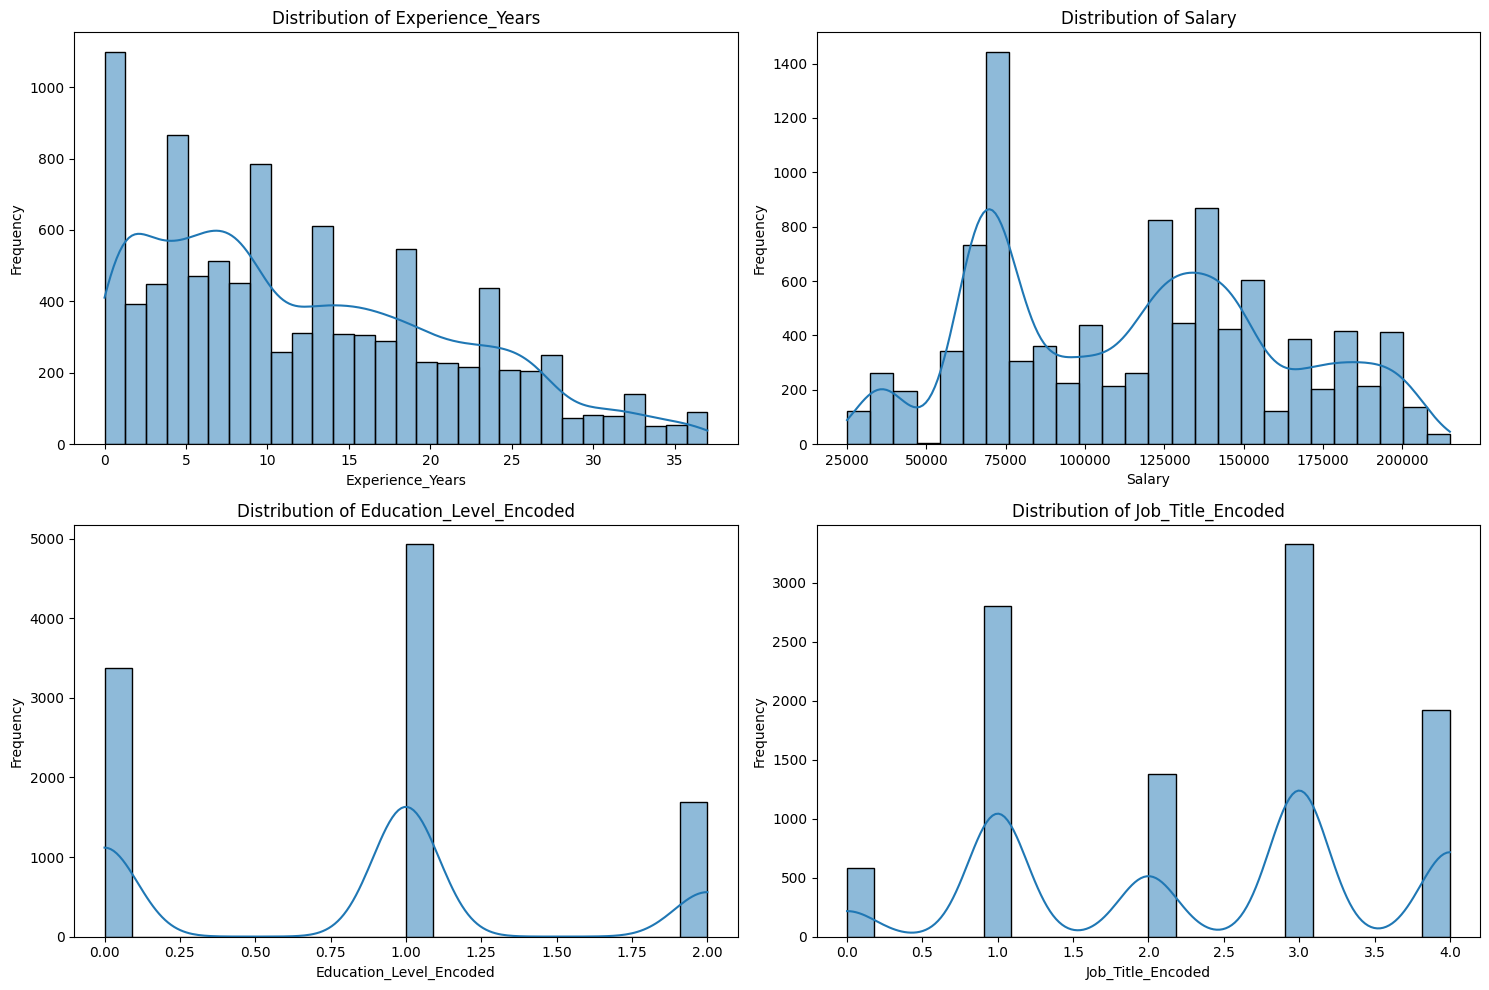

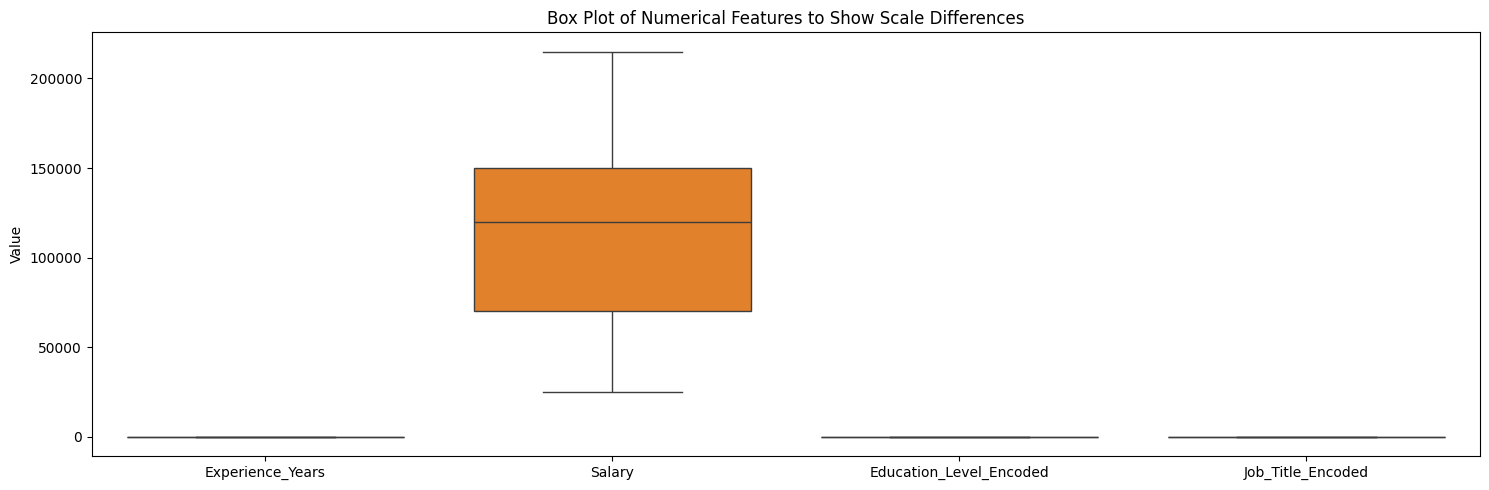

In [23]:
numerical_cols = ['Experience_Years', 'Salary', 'Education_Level_Encoded', 'Job_Title_Encoded']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of subplots
    sns.histplot(Employees_encoded[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
sns.boxplot(data=Employees_encoded[numerical_cols])
plt.title('Box Plot of Numerical Features to Show Scale Differences')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

As you can see from the histograms and especially the box plot, `Salary` has a much larger range and scale compared to `Experience_Years`, `Education_Level_Encoded`, and `Job_Title_Encoded`. If we use these features directly in distance-based clustering algorithms (like K-Means), the `Salary` feature would dominate the distance calculations, making the other features less influential.

**Conclusion for Scaling:** Scaling is essential to ensure that all features contribute equally to the distance metric, preventing features with larger numerical ranges from disproportionately influencing the clustering results.

### Justifying Outlier Analysis: Visual and Quantitative Checks

While descriptive statistics provide a hint, visual and quantitative methods are better for identifying outliers. Let's use box plots and the Interquartile Range (IQR) method.

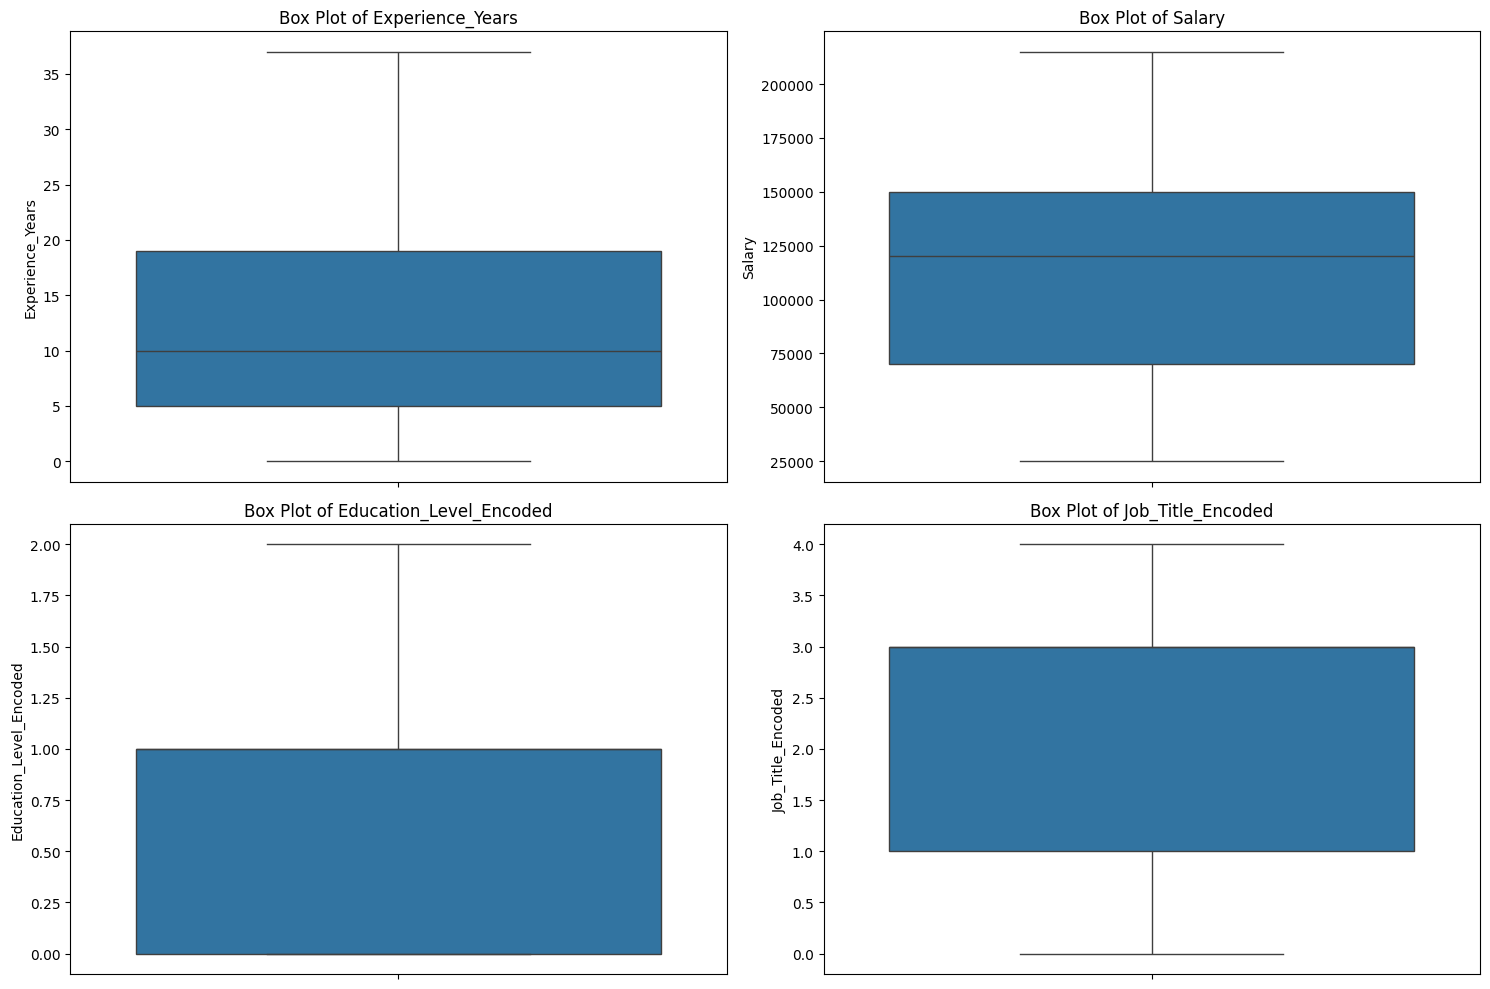

In [24]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=Employees_encoded[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

The box plots visually indicate some potential outliers, particularly in `Experience_Years` and `Salary`. Now, let's use the IQR method to quantitatively identify outliers for these columns.

In [25]:
for col in ['Experience_Years', 'Salary']:
    Q1 = Employees_encoded[col].quantile(0.25)
    Q3 = Employees_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = Employees_encoded[(Employees_encoded[col] < lower_bound) | (Employees_encoded[col] > upper_bound)]
    print(f"Number of outliers in '{col}': {len(outliers)}")
    if len(outliers) > 0:
        print(f"\tExamples of outliers in '{col}':")
        print(outliers[[col]].head())

# You can now decide whether to remove, transform, or keep these outliers based on your domain knowledge and the goals of your clustering.

Number of outliers in 'Experience_Years': 0
Number of outliers in 'Salary': 0


In [26]:
Employees = Employees.drop_duplicates()
print(Employees.info())

<class 'pandas.core.frame.DataFrame'>
Index: 5192 entries, 0 to 9997
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Department        5192 non-null   object
 1   Job_Title         5192 non-null   object
 2   Experience_Years  5192 non-null   int64 
 3   Education_Level   5192 non-null   object
 4   Location          5192 non-null   object
 5   Salary            5192 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 283.9+ KB
None


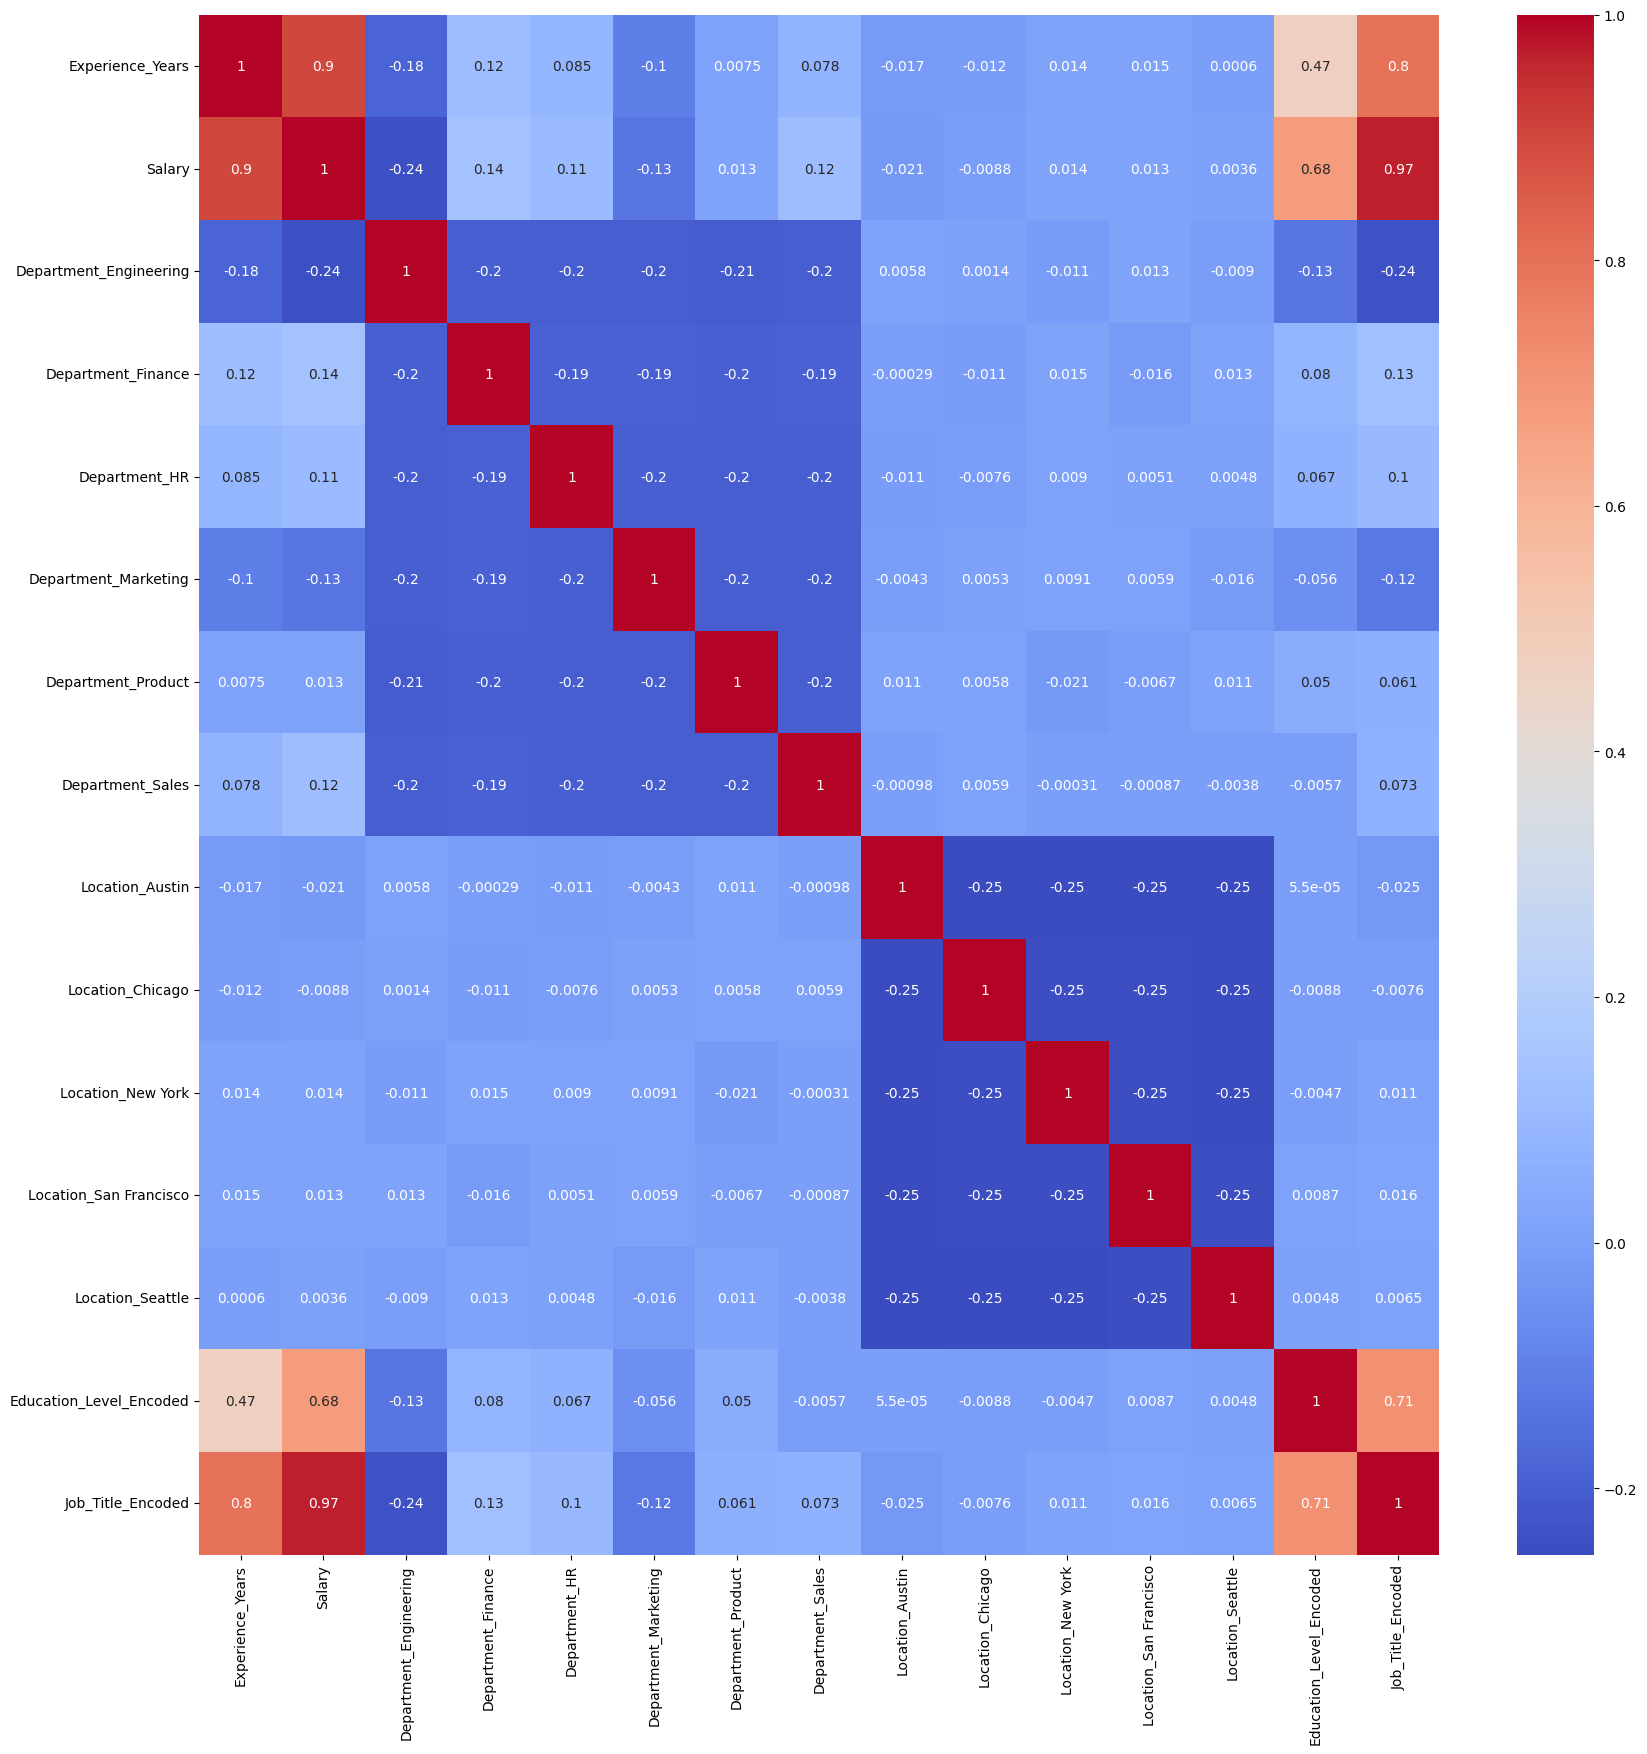

In [29]:
plt.figure(figsize= (20,20))
sns.heatmap(Employees_encoded.corr(), annot = True, cmap= "coolwarm")
plt.show()

In [30]:
Employees_encoded = Employees_encoded.drop_duplicates()
print(Employees_encoded.info())

<class 'pandas.core.frame.DataFrame'>
Index: 5192 entries, 0 to 9997
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Experience_Years         5192 non-null   int64
 1   Salary                   5192 non-null   int64
 2   Department_Engineering   5192 non-null   bool 
 3   Department_Finance       5192 non-null   bool 
 4   Department_HR            5192 non-null   bool 
 5   Department_Marketing     5192 non-null   bool 
 6   Department_Product       5192 non-null   bool 
 7   Department_Sales         5192 non-null   bool 
 8   Location_Austin          5192 non-null   bool 
 9   Location_Chicago         5192 non-null   bool 
 10  Location_New York        5192 non-null   bool 
 11  Location_San Francisco   5192 non-null   bool 
 12  Location_Seattle         5192 non-null   bool 
 13  Education_Level_Encoded  5192 non-null   int64
 14  Job_Title_Encoded        5192 non-null   int64
dtypes: bool(1

In [34]:
from sklearn.preprocessing import StandardScaler

# Identify all columns to be scaled. Since boolean columns are effectively 0s and 1s,
# scaling all columns is appropriate for distance-based algorithms.
features_to_scale = Employees_encoded.columns

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the selected features
Employees_scaled = pd.DataFrame(scaler.fit_transform(Employees_encoded[features_to_scale]), columns=features_to_scale)

# Display the first few rows of the scaled data
print(Employees_scaled.head())

# Display descriptive statistics of the scaled data to verify
print(Employees_scaled.describe())

   Experience_Years    Salary  Department_Engineering  Department_Finance  \
0         -1.458143 -0.890849                2.374739           -0.480840   
1          2.080849  1.581497               -0.421099           -0.480840   
2         -1.458143 -2.185887                2.374739           -0.480840   
3         -0.573395 -1.244041               -0.421099            2.079694   
4         -1.347549 -1.361772               -0.421099           -0.480840   

   Department_HR  Department_Marketing  Department_Product  Department_Sales  \
0      -0.475063             -0.398334           -0.477497         -0.428050   
1      -0.475063             -0.398334           -0.477497          2.336175   
2      -0.475063             -0.398334           -0.477497         -0.428050   
3      -0.475063             -0.398334           -0.477497         -0.428050   
4       2.104985             -0.398334           -0.477497         -0.428050   

   Location_Austin  Location_Chicago  Location_New York 